<a href="https://colab.research.google.com/github/ankan-git-coder/NLP-PROJECTS-/blob/main/Resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import re
import nltk
import spacy
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import pickle

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
from nltk.corpus import stopwords

In [12]:
df = pd.read_csv("Resume.csv")

In [13]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [14]:
df.shape

(2484, 4)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [16]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [17]:
df.describe()

,ID
count,2.484000e+03
mean,3.182616e+07
std,2.145735e+07
min,3.547447e+06
25%,1.754430e+07
50%,2.521031e+07
75%,3.611444e+07
max,9.980612e+07


In [18]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [19]:
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.dropna(inplace=True)

In [22]:
print("Missing Values:")

print("\n")

print(df.isnull().sum())

Missing Values:


ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


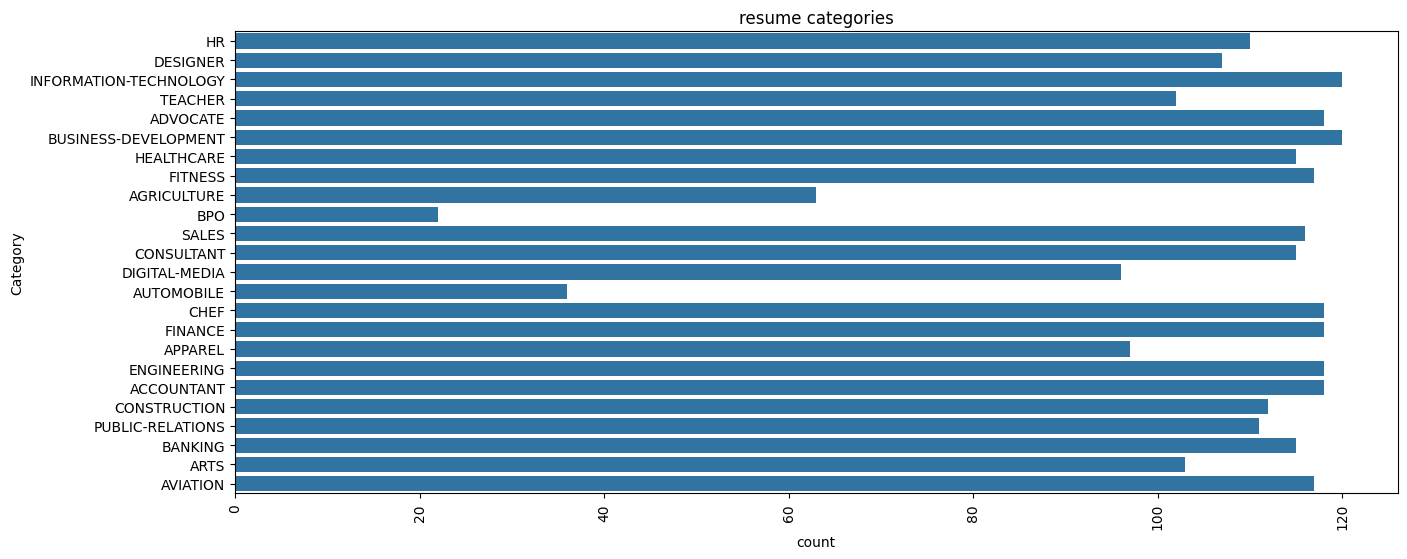

In [31]:
plt.figure(figsize=(15,6))
sns.countplot(y=df['Category'])
plt.xticks(rotation=90)
plt.title("resume categories")
plt.show()


In [32]:
stop_words = set(stopwords.words('english'))
def clean_resume(text):
    text = re.sub('http\S+\s*', ' ', text)

    text = re.sub('RT|cc', ' ', text)

    text = re.sub('#\S+', '', text)

    text = re.sub('@\S+', '  ', text)

    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)

    text = re.sub(r'[^\x00-\x7f]',r' ', text)

    text = re.sub('\s+', ' ', text)
    text = text.lower()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\]'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\]'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1031/2518138250.py:3: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('http\S+\s*', ' ', text)
/tmp/ipykernel_1031/2518138250.py:7: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('#\S+', '', text)
/tmp/ipykernel_1031/2518138250.py:9: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('@\S+', '  ', text)
/tmp/ipykernel_1031/2518138250.py:11: SyntaxWarning: invalid escape sequence '\]'
  text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@

In [33]:
df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)

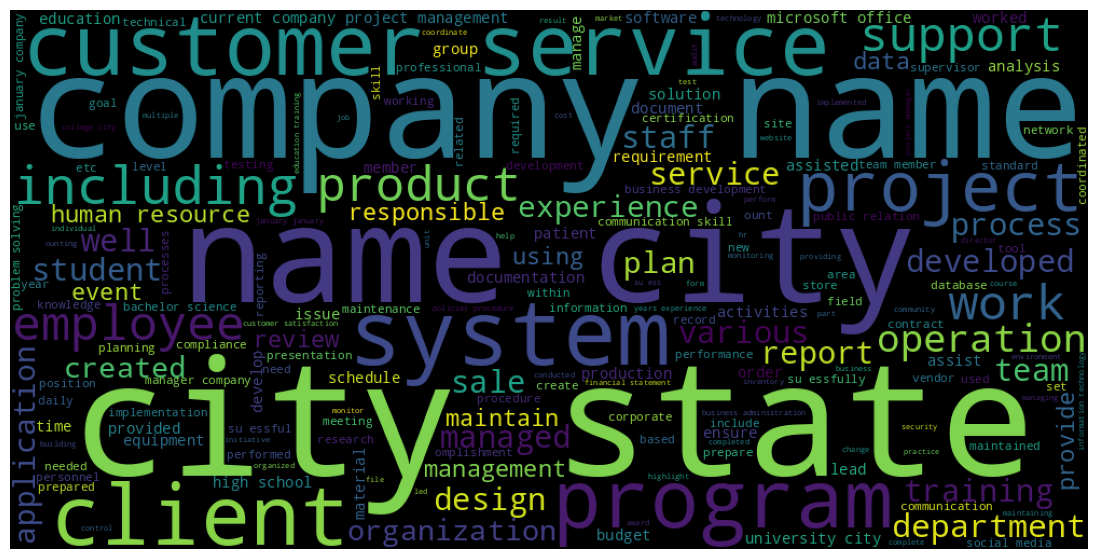

In [34]:
text = " ".join(df['cleaned_resume'])
wordcloud = WordCloud(
    width = 1000,
    height = 500,
    background_color='black'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [38]:
le = LabelEncoder()
df['encoded_category'] = le.fit_transform(df['Category'])

In [40]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['cleaned_resume'])

y = df['encoded_category']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [47]:
## logistic regression

In [42]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("LOGISTIC REGRESSION ACCURACY")
print(accuracy_score(y_test, lr_preds))

LOGISTIC REGRESSION ACCURACY
0.6559356136820925


In [48]:
## naive_bayes

In [43]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_preds = nb_model.predict(X_test)

print("NAIVE BAYES ACCURACY")
print(accuracy_score(y_test, nb_preds))

NAIVE BAYES ACCURACY
0.579476861167002


In [49]:
## random_forest

In [44]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("RANDOM FOREST ACCURACY")
print(accuracy_score(y_test, rf_preds))

RANDOM FOREST ACCURACY
0.744466800804829


In [46]:
## XGboost model

In [45]:
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBOOST ACCURACY")
print(accuracy_score(y_test, xgb_preds))

XGBOOST ACCURACY
0.7806841046277666


In [ ]:
## support vector machine

In [59]:
from sklearn.svm import SVC



svm_model = SVC(kernel='linear', C=1.0, random_state=42)

svm_model.fit(X_train, y_train)

# 3. Predict categories for the unseen test data
svm_preds = svm_model.predict(X_test)

# 4. Evaluate the model's performance
print("--- SUPPORT VECTOR MACHINE ACCURACY ---")
print(accuracy_score(y_test, svm_preds))


--- SUPPORT VECTOR MACHINE ACCURACY ---
0.6338028169014085


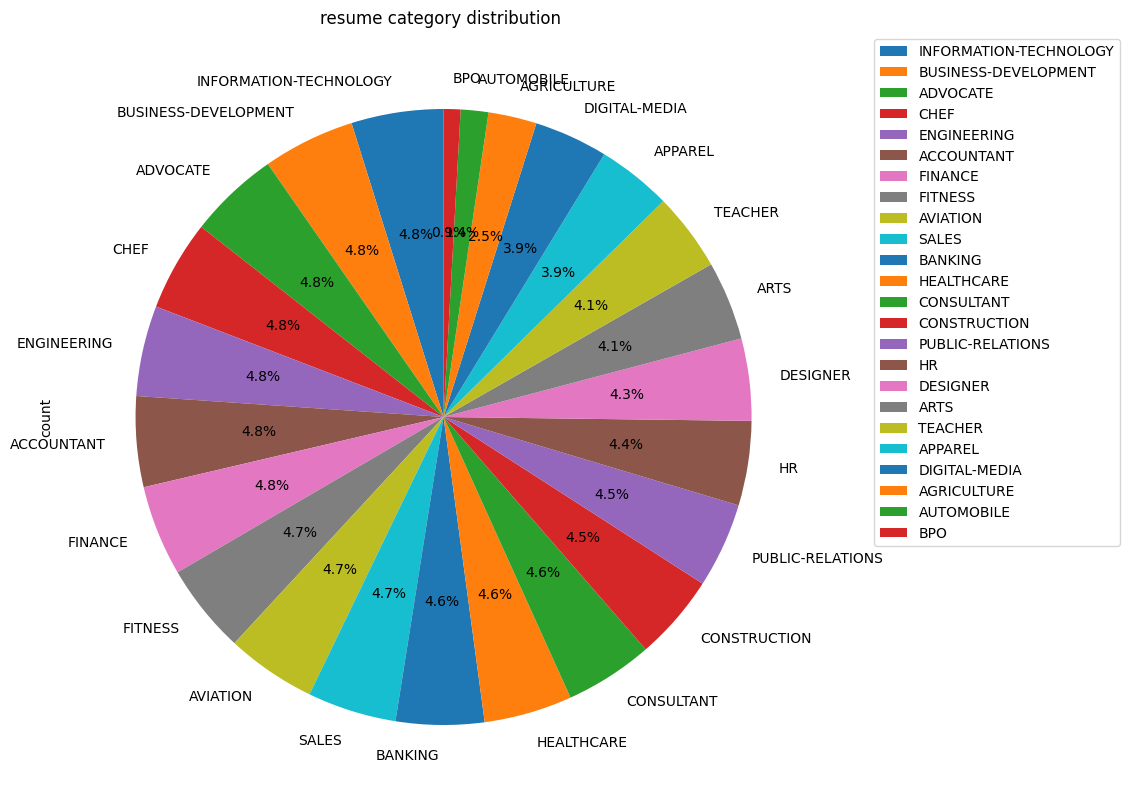

In [53]:
plt.figure(figsize=(10, 10))
df['Category'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)

plt.title("resume category distribution ")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

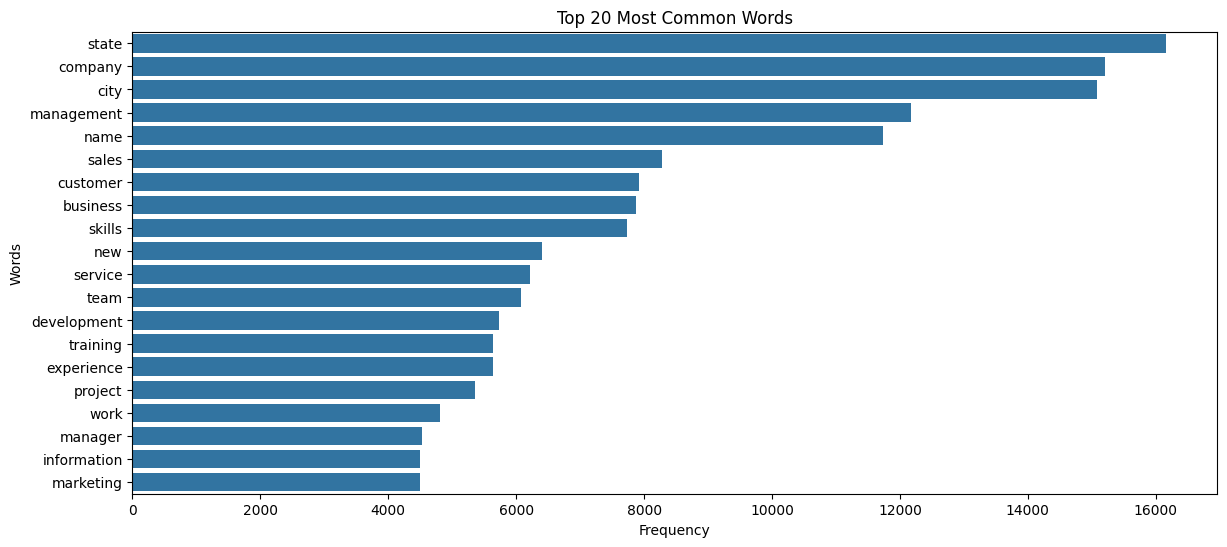

In [54]:
from collections import Counter

all_words = " ".join(df['cleaned_resume']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(14,6))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Common Words")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()

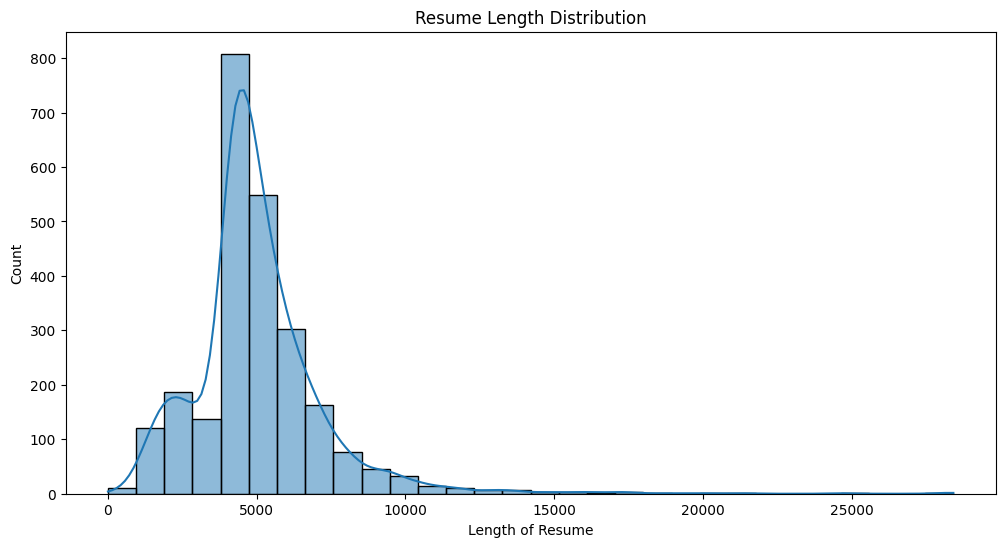

In [55]:
df['resume_length'] = df['cleaned_resume'].apply(len)

plt.figure(figsize=(12,6))

sns.histplot(df['resume_length'], bins=30, kde=True)

plt.title("Resume Length Distribution")

plt.xlabel("Length of Resume")

plt.ylabel("Count")

plt.show()

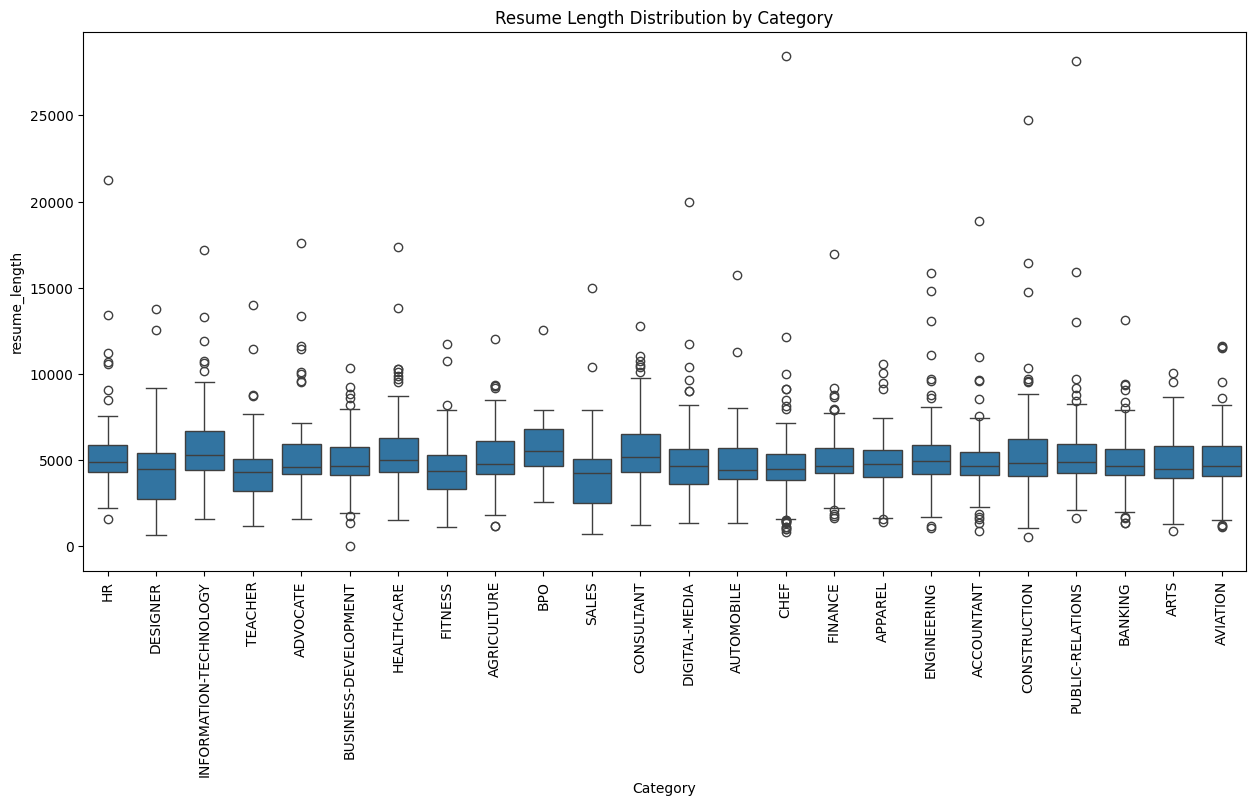

In [56]:
plt.figure(figsize=(15,7))
sns.boxplot(x=df['Category'], y=df['resume_length'])
plt.xticks(rotation=90)
plt.title("Resume Length Distribution by Category")
plt.show()

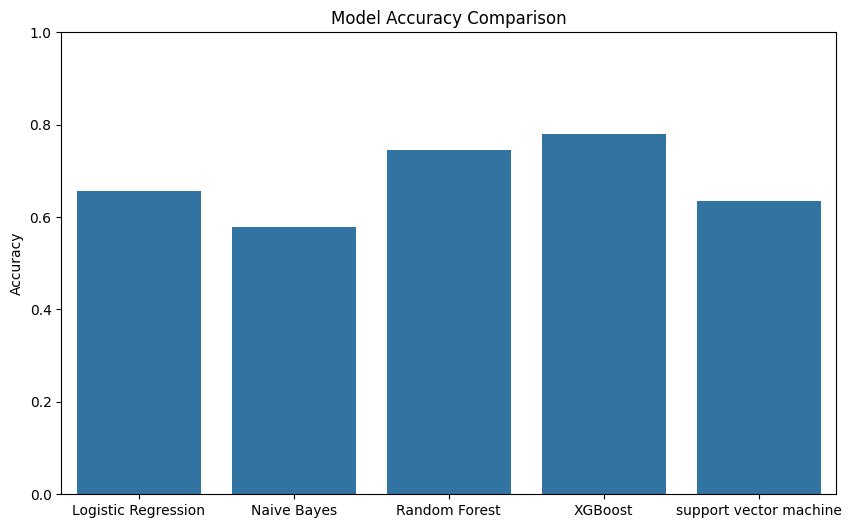

In [61]:
models = ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'XGBoost', 'support vector machine']

accuracies = [
    accuracy_score(y_test, lr_preds),
    accuracy_score(y_test, nb_preds),
    accuracy_score(y_test, rf_preds),
    accuracy_score(y_test, xgb_preds),
    accuracy_score(y_test,svm_preds)
]

plt.figure(figsize=(10,6))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

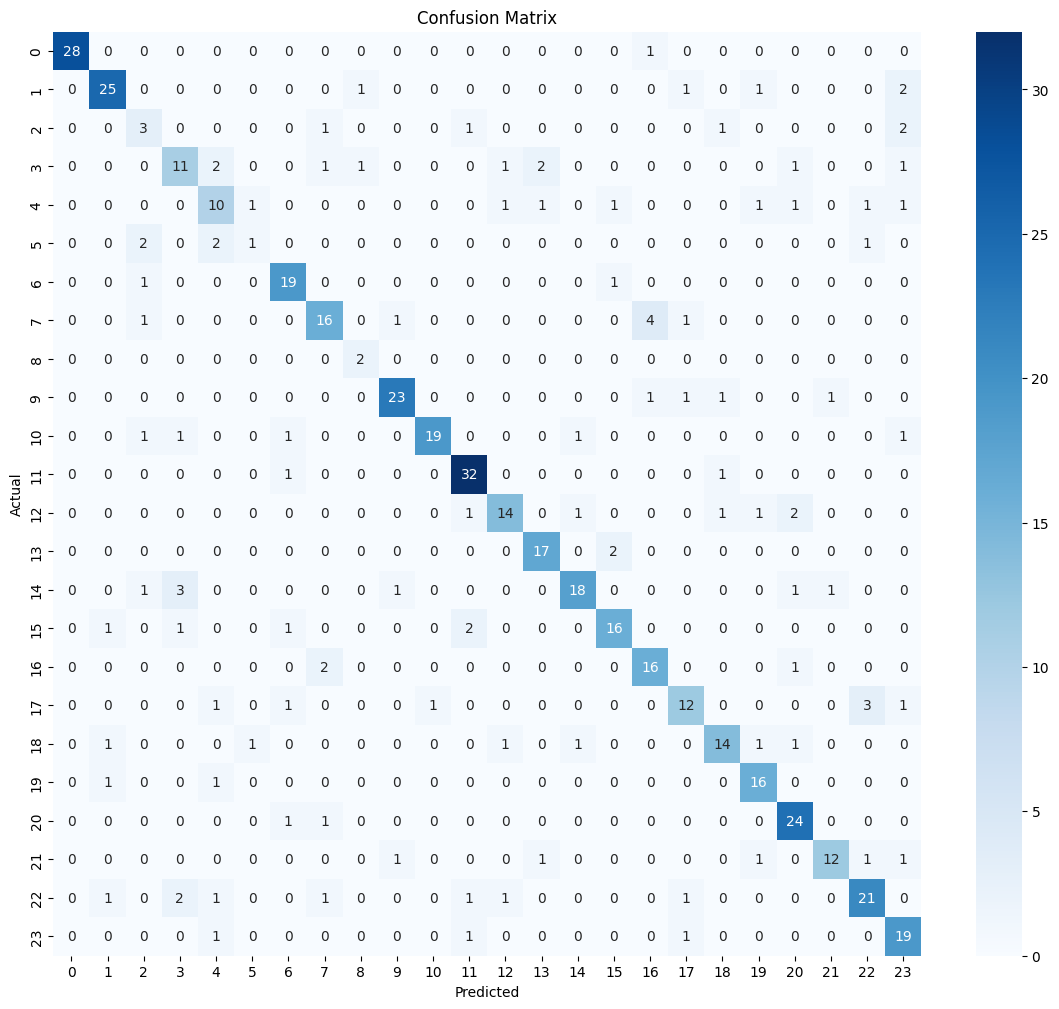

In [62]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


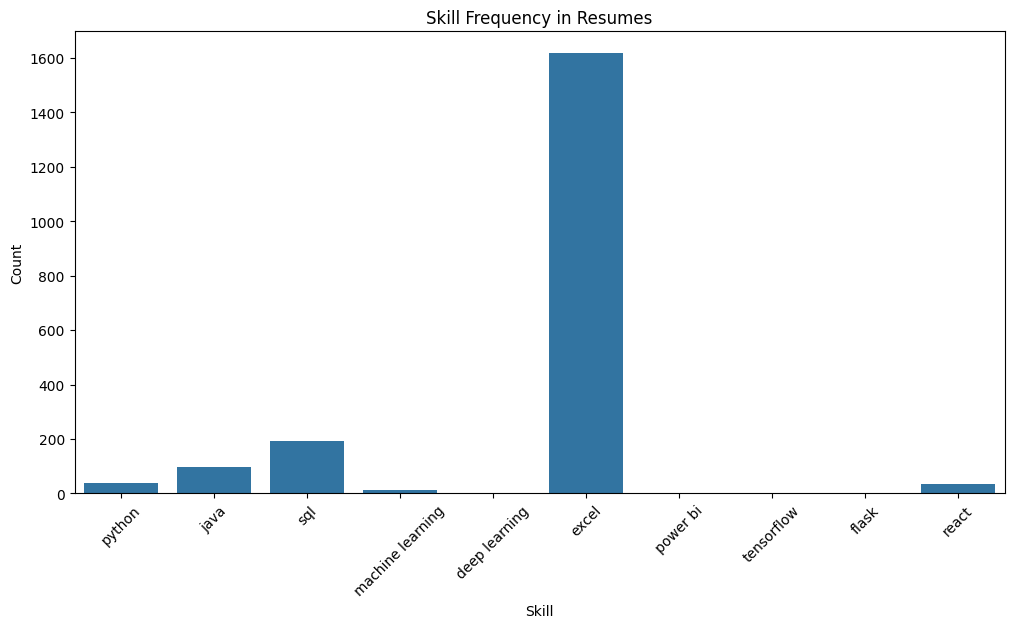

In [63]:
skills = [
    'python',
    'java',
    'sql',
    'machine learning',
    'deep learning',
    'excel',
    'power bi',
    'tensorflow',
    'flask',
    'react'
]

skill_count = {}

for skill in skills:
    count = df['cleaned_resume'].str.contains(skill).sum()
    skill_count[skill] = count

skill_df = pd.DataFrame({
    'Skill': skill_count.keys(),
    'Count': skill_count.values()
})

plt.figure(figsize=(12,6))

sns.barplot(
    x='Skill',
    y='Count',
    data=skill_df
)

plt.title("Skill Frequency in Resumes")

plt.xticks(rotation=45)

plt.show()
